In [34]:
%load_ext autoreload
%autoreload 2

import jax 
jax.config.update('jax_enable_checks', False)
import sys
import os
# import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from typing import NamedTuple, Tuple, Dict, List
import jax.experimental.checkify as checkify # Import checkify
from hydra import initialize, compose
from omegaconf import DictConfig, OmegaConf
from jax import config
import chex
config.update("jax_enable_x64", True)

import matplotlib.pyplot as plt
import matplotlib as mpl
import jax.random as jr


# IMPORTANT: Set this to the correct root directory of your project
# Use an absolute path for reliability
root_dir = r"c:\Users\jimvo\Documents\Recurrent-PPO-Jax" # Use the path you provided

if not os.path.isdir(root_dir):
    print(f"Error: Directory not found: {root_dir}")
    print("Please update the 'root_dir' variable to the correct path.")
else:
    if root_dir not in sys.path:
        sys.path.append(root_dir)
        print(f"Added {root_dir} to sys.path")

# Attempt to import your sampler functions
try:
    # Assuming your functions are in this specific module path
    from src.tasks.envs.jax_env_f.jax_function_samplers import (
        create_env_params,
        initialize_sampler_dispatch,
        compute_y_sampler_dispatch,
        ALL_POSSIBLE_FUNCTION_NAMES, # This list is crucial
        EnvParams # Import if type hinting is desired elsewhere
    )
    from src.gp.gpjax import BayesianOptimizer, BOState, BOStaticParams, calculate_ucb

    
    print("Successfully imported sampler functions.")
except ImportError as e:
    print(f"Error importing sampler functions: {e}")
    print("Please ensure 'root_dir' is correct and the module path exists:")
    print("src.tasks.envs.function_envs.jax_samplers.jax_function_samplers")
except Exception as e:
    print(f"An unexpected error occurred during import: {e}")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
An unexpected error occurred during import: module 'src.tasks.envs.jax_env_f.function_environments.kernel_sampler' has no attribute 'initialize_func'


In [35]:


# Define your configuration path and name, similar to your @hydra.main decorator
config_path_relative = "../../../../config" # Adjusted path
config_name_value = "sweep_test" # Or whatever your main config file is named
version_base_value = None # Or your specific Hydra version base

# Initialize Hydra within a context manager.
# This is generally recommended for use in notebooks or scripts
# to avoid polluting the global Hydra state if you run multiple initializations.
with initialize(version_base=version_base_value, config_path=config_path_relative):
    # Compose your configuration
    # 'cfg' will be a DictConfig object, just like in your 'main' function
    cfg: DictConfig = compose(config_name=config_name_value)

    # Now you can convert it to a Python container (dict/list) with interpolations resolved
    # This is equivalent to: conf = OmegaConf.to_container(config, resolve=True)
    conf_dict = OmegaConf.to_container(cfg.task, resolve=True)
    conf_dict['function_types'] = ['poly', 'matern52', 'ackley', 'neg_abs', 'gaussian', 'branin', 'hartmann6', 'rosenbrock', ' michalewicz', 'eggholder', 'cosine']

    # 'conf_dict' now holds your configuration as a Python dictionary
    # You can use it for your testing purposes in the notebook
    print("Successfully loaded and resolved configuration:")





Successfully loaded and resolved configuration:


youo 200 {} RBF_kernel dict_keys(['action_dim', 'function_types', 'total_episode_samples', 'batches', 'max_batches', 'bounds', 'poly_env', 'gaussian_env', 'ackley_env', 'matern52_env', 'neg_abs_env', 'branin_env', 'cosine_env', 'egg_env', 'hartmann_env', 'matern52_kernel_env', 'rbf_kernel_env', 'rosenbrock_env', 'RBF_kernel_env'])
youo 200 {} matern32_kernel dict_keys(['action_dim', 'function_types', 'total_episode_samples', 'batches', 'max_batches', 'bounds', 'poly_env', 'gaussian_env', 'ackley_env', 'matern52_env', 'neg_abs_env', 'branin_env', 'cosine_env', 'egg_env', 'hartmann_env', 'matern52_kernel_env', 'rbf_kernel_env', 'rosenbrock_env', 'RBF_kernel_env'])
youo 200 {'bounds': [-3, 3], 'kernel_type_str': 'Matern52'} matern52_kernel dict_keys(['action_dim', 'function_types', 'total_episode_samples', 'batches', 'max_batches', 'bounds', 'poly_env', 'gaussian_env', 'ackley_env', 'matern52_env', 'neg_abs_env', 'branin_env', 'cosine_env', 'egg_env', 'hartmann_env', 'matern52_kernel_env'

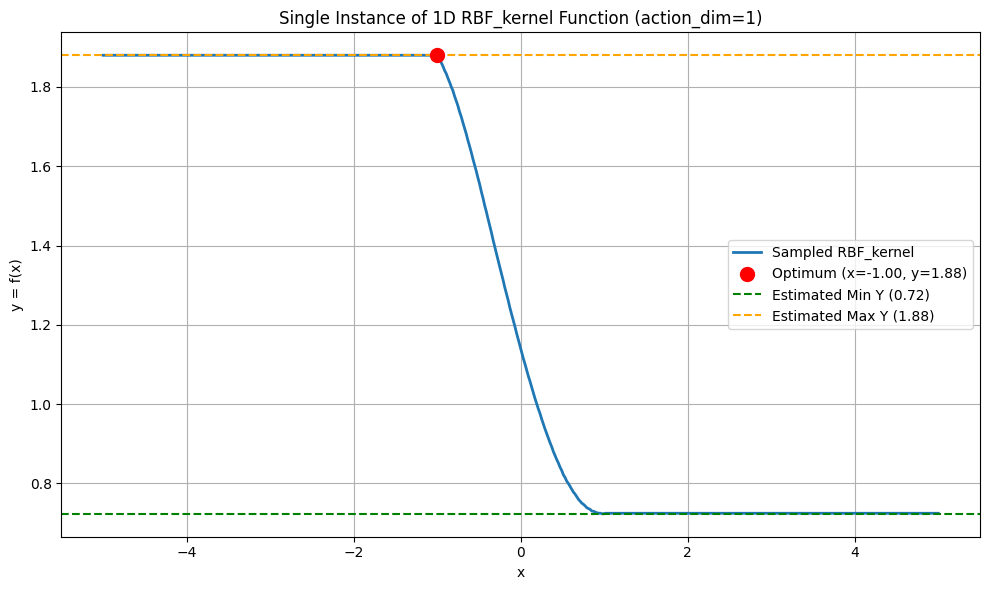


Plotting complete.


In [40]:
from src.tasks.envs.jax_env_f.jax_disp_samplers import (
        create_env_params,
        initialize_sampler_dispatch,
        compute_y_sampler_dispatch,
        ALL_POSSIBLE_FUNCTION_NAMES, # This list is crucial
        EnvParams # Import if type hinting is desired elsewhere
    )
# --- Configuration for Plotting ---
function_name_to_plot = "RBF_kernel"  # Change this to the function you want to plot
plot_action_dimension = 1          # For 1D plots

# Plotting range and resolution (can be overridden by specific function bounds)
default_x_plot_min, default_x_plot_max = -5.0, 5.0
num_plot_points = 500




# --- Prepare Specific Configuration for Plotting ---
# Start with an empty dict for the config to be passed to create_env_params
plot_specific_conf = {}

# 1. Set essential parameters for plotting the single function
plot_specific_conf["action_dim"] = plot_action_dimension
plot_specific_conf["function_types"] = [function_name_to_plot]

# 2. Copy necessary global settings from hydra_master_conf, with defaults
# These are top-level keys expected by create_env_params
plot_specific_conf["total_episode_samples"] = conf_dict.get("total_episode_samples", 1000)
plot_specific_conf["batches"] = conf_dict.get("batches", [1])
plot_specific_conf["max_batches"] = conf_dict.get("max_batches", 1)
# Global bounds: Use function-specific if available, then hydra global, then script default
# This will be further refined when getting actual_bounds_for_plot from sampler_params later.
fn_env_key = f"{function_name_to_plot}_env"
default_plot_bounds = (default_x_plot_min, default_x_plot_max)
if fn_env_key in conf_dict and "bounds" in conf_dict[fn_env_key]:
    # Check if bounds in specific env config is a list of tuples (e.g. Branin) or a single tuple
    specific_bounds = conf_dict[fn_env_key]["bounds"]
    if isinstance(specific_bounds, list) and len(specific_bounds) > 0 and isinstance(specific_bounds[0], (list, tuple)):
        # Multi-dimensional bounds, take the first for 1D plotting default
         plot_specific_conf["bounds"] = tuple(specific_bounds[0])
    else:
         plot_specific_conf["bounds"] = tuple(specific_bounds)
else:
    plot_specific_conf["bounds"] = tuple(conf_dict.get("bounds", default_plot_bounds))


# 3. Copy ALL specific '[function_name]_env' configurations from hydra_master_conf.
# create_env_params (specifically, get_specific_config_template_for_function) needs these
# to build the full sampler_configs template in EnvParams, even for functions not
# currently in plot_specific_conf["function_types"].
for key, value in conf_dict.items():
    if key.endswith("_env"):
        plot_specific_conf[key] = value
    # Ensure that if a specific _env config is missing from Hydra for the function_name_to_plot,
    # we add a minimal one so get_specific_config_template doesn't fail.
    # This is important if hydra_master_conf is sparse.
    # The get_specific_config_template functions should ideally handle missing _env keys gracefully using their own defaults.

# Ensure the _env config for the function_name_to_plot exists, even if empty,
# so get_specific_config_template can try to access it.
if f"{function_name_to_plot}_env" not in plot_specific_conf:
    plot_specific_conf[f"{function_name_to_plot}_env"] = {}


# --- Dimension Compatibility Check (same as before) ---
if function_name_to_plot == "branin" and plot_action_dimension != 2:
    print(f"Warning: Branin is 2D. Plotting with action_dim={plot_action_dimension} may be misleading.")
    # For Branin, you might want to force plot_specific_conf["action_dim"] = 2
    # and then adapt the x_plot generation and plotting to 2D (e.g., contour plot).
    # This script will proceed with 1D plotting using the first dimension's bounds.
elif function_name_to_plot == "hartmann6" and plot_action_dimension != 6:
    print(f"Warning: Hartmann6 is 6D. Plotting with action_dim={plot_action_dimension} may be misleading.")
elif function_name_to_plot == "eggholder" and plot_action_dimension < 2:
     print(f"Warning: Eggholder is >=2D. Plotting with action_dim={plot_action_dimension} may be misleading.")


# --- Create EnvParams ---
# This uses your new create_env_params function with the tailored plot_specific_conf

env_params = create_env_params(plot_specific_conf)
print(f"\nEnvParams created for plotting: {function_name_to_plot} with action_dim: {env_params.action_dim}")
# print("Dispatch config initializers:", env_params.dispatch_config.initializers)

# --- Initialize Sampler ---
key = jax.random.PRNGKey(0)

try:
    global_sampler_index = ALL_POSSIBLE_FUNCTION_NAMES.index(function_name_to_plot)
except ValueError:
    print(f"Error: Function name '{function_name_to_plot}' not found in ALL_POSSIBLE_FUNCTION_NAMES.")
    print(f"Available names: {ALL_POSSIBLE_FUNCTION_NAMES}")
    exit()

sampler_params = initialize_sampler_dispatch(key, global_sampler_index, env_params)
print("\nSampler parameters initialized successfully.")
print("--- Initialized Sampler Common Parameters ---")
for k, v_item in sampler_params['common'].items(): # Renamed v to v_item
    print(f"  {k}: {v_item}")


# --- Generate Data for Plotting ---
actual_bounds_for_plot = sampler_params['common']['bounds']
# Handle cases like Branin where bounds might be a list of tuples
if isinstance(actual_bounds_for_plot[0], (list, tuple)) and env_params.action_dim > 1 and plot_action_dimension == 1 :
    print(f"Warning: Plotting first dimension of multi-dimensional bounds: {actual_bounds_for_plot}")
    actual_bounds_for_plot = actual_bounds_for_plot[0]
elif not (isinstance(actual_bounds_for_plot, (list, tuple)) and len(actual_bounds_for_plot) == 2 and isinstance(actual_bounds_for_plot[0], (int, float))):
    print(f"Warning: Unexpected bounds format {actual_bounds_for_plot}, falling back to default plot bounds.")
    actual_bounds_for_plot = default_plot_bounds


print(f"\nBounds for plotting ({function_name_to_plot}): {actual_bounds_for_plot}")

x_plot_vals = jnp.linspace(actual_bounds_for_plot[0], actual_bounds_for_plot[1], num_plot_points)
# x_plot needs to have shape (num_plot_points, env_params.action_dim)
# env_params.action_dim is now plot_action_dimension (e.g., 1)
x_plot = x_plot_vals.reshape(-1, env_params.action_dim)


compute_single_y_for_plot = lambda x_point: compute_y_sampler_dispatch(x_point, sampler_params, env_params)
jitted_compute_single_y = jax.jit(compute_single_y_for_plot)
y_plot = jax.vmap(jitted_compute_single_y)(x_plot)

print(f"\nGenerated x_plot shape: {x_plot.shape}, y_plot shape: {y_plot.shape}")

# --- Plotting ---
plt.figure(figsize=(10, 6))
plt.plot(x_plot_vals, y_plot.flatten(), label=f'Sampled {function_name_to_plot}', linewidth=2)

opt_x_array = sampler_params["common"]['optimum_point']
max_y_val = sampler_params["common"]['max_y']
min_y_val = sampler_params["common"]['min_y']

opt_x_plot_coord = opt_x_array[0] if env_params.action_dim == 1 else opt_x_array[0] # Default to first component if N-D

plt.scatter([opt_x_plot_coord], [max_y_val], color='red', s=100, zorder=5,
            label=f'Optimum (x={opt_x_plot_coord:.2f}, y={max_y_val:.2f})')
plt.axhline(min_y_val, color='green', linestyle='--', label=f'Estimated Min Y ({min_y_val:.2f})')
plt.axhline(max_y_val, color='orange', linestyle='--', label=f'Estimated Max Y ({max_y_val:.2f})')

plt.title(f'Single Instance of 1D {function_name_to_plot} Function (action_dim={env_params.action_dim})')
plt.xlabel('x')
plt.ylabel('y = f(x)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nPlotting complete.")


youo 200 {} RBF_kernel dict_keys(['action_dim', 'function_types', 'total_episode_samples', 'batches', 'max_batches', 'bounds', 'poly_env', 'gaussian_env', 'ackley_env', 'matern52_env', 'neg_abs_env', 'branin_env', 'cosine_env', 'egg_env', 'hartmann_env', 'matern52_kernel_env', 'rbf_kernel_env', 'rosenbrock_env'])
youo 200 {} matern32_kernel dict_keys(['action_dim', 'function_types', 'total_episode_samples', 'batches', 'max_batches', 'bounds', 'poly_env', 'gaussian_env', 'ackley_env', 'matern52_env', 'neg_abs_env', 'branin_env', 'cosine_env', 'egg_env', 'hartmann_env', 'matern52_kernel_env', 'rbf_kernel_env', 'rosenbrock_env'])
youo 200 {'bounds': [-3, 3], 'kernel_type_str': 'Matern52'} matern52_kernel dict_keys(['action_dim', 'function_types', 'total_episode_samples', 'batches', 'max_batches', 'bounds', 'poly_env', 'gaussian_env', 'ackley_env', 'matern52_env', 'neg_abs_env', 'branin_env', 'cosine_env', 'egg_env', 'hartmann_env', 'matern52_kernel_env', 'rbf_kernel_env', 'rosenbrock_env'

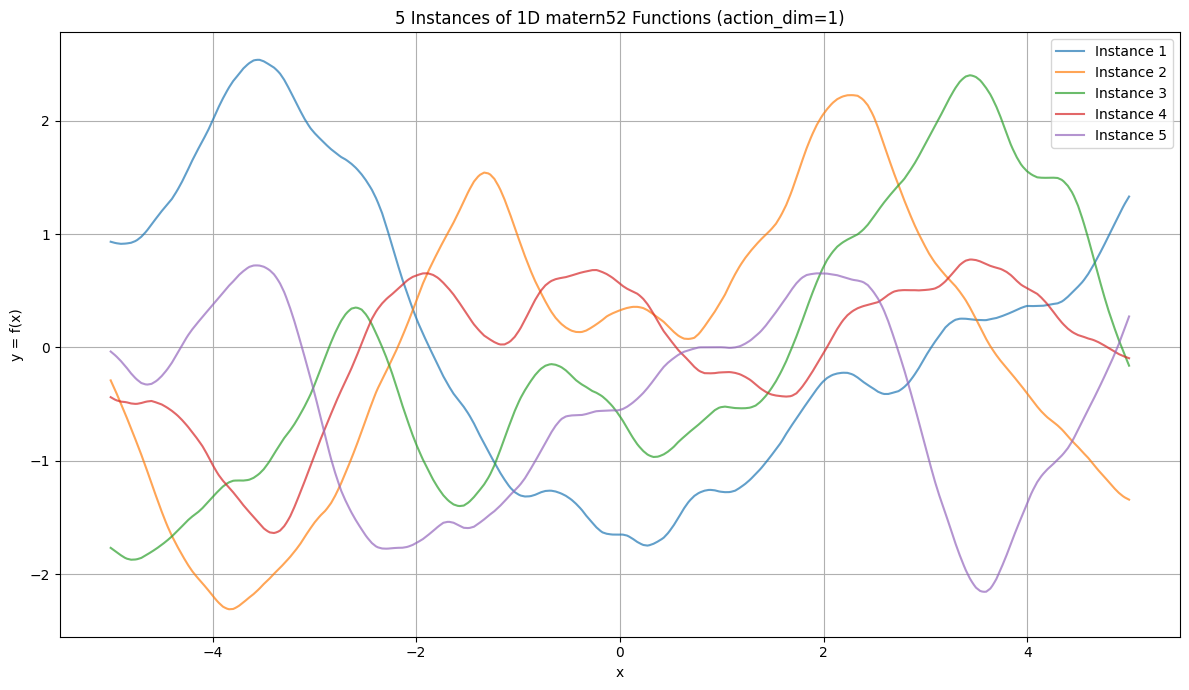


Multi-instance plotting complete.


In [37]:


# --- Configuration for Plotting ---
function_name_to_plot = "matern52"  # Change this: "ackley", "poly", "gaussian", "matern52", etc.
plot_action_dimension = 1          # For 1D plots
num_functions_to_plot = 5
num_plot_points = 500



# --- Prepare Specific Configuration for Plotting ---
plot_specific_conf = {}
plot_specific_conf["action_dim"] = plot_action_dimension
plot_specific_conf["function_types"] = [function_name_to_plot] # Only the one we want to plot

# Copy necessary global settings from hydra_master_conf, with defaults
plot_specific_conf["total_episode_samples"] = conf_dict.get("total_episode_samples", 1000)
plot_specific_conf["batches"] = conf_dict.get("batches", [1])
plot_specific_conf["max_batches"] = conf_dict.get("max_batches", 1)

# Global bounds for create_env_params (will be used if specific func bounds not in its _env config)
# This default_plot_bounds is for the x-axis of the plot itself.
default_plot_bounds_tuple = (default_x_plot_min, default_x_plot_max)
plot_specific_conf["bounds"] = tuple(conf_dict.get("bounds", default_plot_bounds_tuple))


# Copy ALL specific '[function_name]_env' configurations from hydra_master_conf.
for key_config, value_config in conf_dict.items(): # Renamed key, value to avoid conflict
    if key_config.endswith("_env"):
        plot_specific_conf[key_config] = value_config

# Ensure the _env config for the function_name_to_plot exists
fn_env_key = f"{function_name_to_plot}_env"
if fn_env_key not in plot_specific_conf:
    plot_specific_conf[fn_env_key] = {} # Needs to exist for get_specific_config_template

# --- Dimension Compatibility Check ---
# (Add your checks for Branin, Hartmann6, Eggholder if needed, similar to single plot script)
if function_name_to_plot == "branin" and plot_action_dimension != 2:
    print(f"Warning: Branin is 2D. Plotting with action_dim={plot_action_dimension} is for one slice/component.")
# ... other checks

# --- Create EnvParams (once) ---
env_params = create_env_params(plot_specific_conf)
print(f"\nEnvParams created for plotting multiple instances of: {function_name_to_plot} with action_dim: {env_params.action_dim}")

# --- Get Global Sampler Index ---
try:
    global_sampler_index = ALL_POSSIBLE_FUNCTION_NAMES.index(function_name_to_plot)
except ValueError:
    print(f"Error: Function name '{function_name_to_plot}' not found in ALL_POSSIBLE_FUNCTION_NAMES.")
    print(f"Available names: {ALL_POSSIBLE_FUNCTION_NAMES}")
    exit()

# --- Determine Plotting X-axis Range ---
# Use the bounds defined in the EnvParams template for the specific function being plotted.
# This ensures x_plot is consistent for all instances.
specific_func_config_template = env_params.sampler_configs['specific'].get(function_name_to_plot, {})
plot_bounds_for_x_axis = specific_func_config_template.get('bounds', plot_specific_conf["bounds"])

# Handle cases like Branin where 'bounds' might be a list of tuples for different dimensions
if isinstance(plot_bounds_for_x_axis, list) and len(plot_bounds_for_x_axis) > 0 and isinstance(plot_bounds_for_x_axis[0], (list, tuple)):
    if plot_action_dimension == 1 and env_params.action_dim >= 1 : # if plotting 1D of a potentially N-D func
        print(f"Warning: Using first dimension's bounds {plot_bounds_for_x_axis[0]} for 1D plot of {function_name_to_plot}.")
        plot_bounds_for_x_axis = plot_bounds_for_x_axis[0]
    # Add more sophisticated logic here if action_dim > 1 for plotting (e.g. contour plots)
elif not (isinstance(plot_bounds_for_x_axis, (tuple, list)) and len(plot_bounds_for_x_axis) == 2 and isinstance(plot_bounds_for_x_axis[0], (int, float))):
    print(f"Warning: Unexpected bounds format {plot_bounds_for_x_axis} from template, falling back to global plot config bounds.")
    plot_bounds_for_x_axis = plot_specific_conf["bounds"]

print(f"\nGenerating x_plot values over bounds: {plot_bounds_for_x_axis}")
x_plot_vals = jnp.linspace(plot_bounds_for_x_axis[0], plot_bounds_for_x_axis[1], num_plot_points)
# x_plot needs to have shape (num_plot_points, env_params.action_dim)
# env_params.action_dim is plot_action_dimension (e.g., 1) for this script
x_plot = x_plot_vals.reshape(-1, env_params.action_dim)


# --- Plotting Loop ---
plt.figure(figsize=(12, 7))
master_key = jax.random.PRNGKey(99) # Starting key for all instances

for i in range(num_functions_to_plot):
    master_key, instance_key = jax.random.split(master_key)

    # Initialize the sampler for this instance
    # env_params is reused; only the key changes to get a new random instance
    sampler_params_instance = initialize_sampler_dispatch(instance_key, global_sampler_index, env_params)
    print(f"\nInstance {i+1} Initialized. Max Y: {sampler_params_instance['common']['max_y']:.3f}, Min Y: {sampler_params_instance['common']['min_y']:.3f}")

    # Compute y values for this specific function instance
    # Define a lambda for the current instance's sampler_params
    compute_single_y_for_instance = lambda x_point: compute_y_sampler_dispatch(x_point, sampler_params_instance, env_params)
    jitted_compute_y_for_instance = jax.jit(compute_single_y_for_instance)
    
    y_plot_instance = jax.vmap(jitted_compute_y_for_instance)(x_plot)

    # Plot this function instance
    plt.plot(x_plot_vals, y_plot_instance.flatten(), label=f'Instance {i+1}', alpha=0.7)

# --- Final Plot Details ---
plt.title(f'{num_functions_to_plot} Instances of 1D {function_name_to_plot} Functions (action_dim={env_params.action_dim})')
plt.xlabel('x')
plt.ylabel('y = f(x)')
if num_functions_to_plot <= 10: # Avoid overly crowded legend
    plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nMulti-instance plotting complete.")


youo 200 {} RBF_kernel dict_keys(['action_dim', 'function_types', 'total_episode_samples', 'batches', 'max_batches', 'bounds', 'poly_env', 'gaussian_env', 'ackley_env', 'matern52_env', 'neg_abs_env', 'branin_env', 'cosine_env', 'egg_env', 'hartmann_env', 'matern52_kernel_env', 'rbf_kernel_env', 'rosenbrock_env', 'michalewicz_env'])
youo 200 {} matern32_kernel dict_keys(['action_dim', 'function_types', 'total_episode_samples', 'batches', 'max_batches', 'bounds', 'poly_env', 'gaussian_env', 'ackley_env', 'matern52_env', 'neg_abs_env', 'branin_env', 'cosine_env', 'egg_env', 'hartmann_env', 'matern52_kernel_env', 'rbf_kernel_env', 'rosenbrock_env', 'michalewicz_env'])
youo 200 {'bounds': [-3, 3], 'kernel_type_str': 'Matern52'} matern52_kernel dict_keys(['action_dim', 'function_types', 'total_episode_samples', 'batches', 'max_batches', 'bounds', 'poly_env', 'gaussian_env', 'ackley_env', 'matern52_env', 'neg_abs_env', 'branin_env', 'cosine_env', 'egg_env', 'hartmann_env', 'matern52_kernel_en

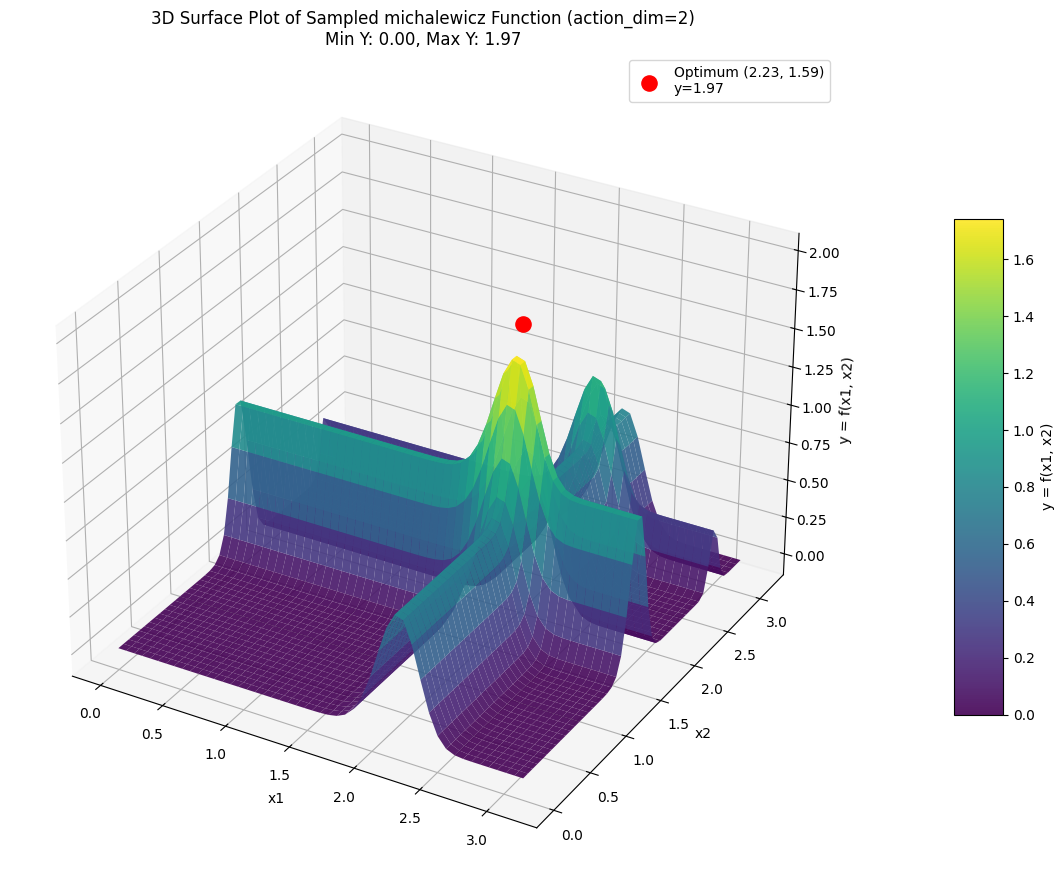

Plotting complete.


In [38]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib.cm as cm # For colormaps
from mpl_toolkits.mplot3d import Axes3D # Explicit import for 3D projection
import chex


# --- Configuration for 2D Plotting ---
# Select the function to plot by its registered name
function_name_to_plot = "michalewicz"  # Examples: "ackley", "branin", "rosenbrock"
# function_name_to_plot = "branin" # Branin is inherently 2D
# function_name_to_plot = "rosenbrock"

plot_action_dimension = 2          # Crucial: Set to 2 for 2D plots
num_points_per_dim = 50           # Resolution for each dimension of the grid (e.g., 50x50 points)




# --- Prepare Specific Configuration for Plotting ---
plot_specific_conf = {}
plot_specific_conf["action_dim"] = plot_action_dimension # Set to 2
plot_specific_conf["function_types"] = [function_name_to_plot]

# Copy necessary global settings from hydra_master_conf, with defaults
plot_specific_conf["total_episode_samples"] = conf_dict.get("total_episode_samples", 1000)
plot_specific_conf["batches"] = conf_dict.get("batches", [1])
plot_specific_conf["max_batches"] = conf_dict.get("max_batches", 1)

# Global bounds for create_env_params.
# For 2D, if a function like Branin has specific per-axis bounds, its _env config should reflect that.
# Otherwise, these global bounds will be used for both x1 and x2 axes of the plot.
default_plot_bounds_tuple = (default_x_plot_min, default_x_plot_max)
plot_specific_conf["bounds"] = tuple(conf_dict.get("bounds", default_plot_bounds_tuple))

# Copy ALL specific '[function_name]_env' configurations from hydra_master_conf.
for key_config, value_config in conf_dict.items():
    if key_config.endswith("_env"):
        plot_specific_conf[key_config] = value_config

# Ensure the _env config for the function_name_to_plot exists
fn_env_key = f"{function_name_to_plot}_env"
if fn_env_key not in plot_specific_conf:
    plot_specific_conf[fn_env_key] = {}

# --- Dimension Compatibility Check ---
# Add checks if a function is NOT suitable for 2D plotting (e.g., if it's strictly 6D like Hartmann6)
if function_name_to_plot == "hartmann6" and plot_action_dimension != 6:
    print(f"Warning: Hartmann6 is 6D. Attempting to plot with action_dim={plot_action_dimension} is not standard.")
    # Consider exiting or adjusting plot_action_dimension for such cases.

# --- Create EnvParams ---
env_params = create_env_params(plot_specific_conf)
print(f"\nEnvParams created for 2D plotting: {function_name_to_plot} with action_dim: {env_params.action_dim}")
if env_params.action_dim != 2:
    print(f"Warning: EnvParams action_dim is {env_params.action_dim}, but script is set for 2D plotting. Ensure configuration is correct.")
    # This might happen if plot_specific_conf["action_dim"] was overridden by hydra_master_conf unintentionally
    # or if the function intrinsically has a different dimension. For plotting, we need action_dim=2.

# --- Initialize Sampler ---
key = jax.random.PRNGKey(66) # Consistent key for reproducibility

try:
    global_sampler_index = ALL_POSSIBLE_FUNCTION_NAMES.index(function_name_to_plot)
except ValueError:
    print(f"Error: Function name '{function_name_to_plot}' not found in ALL_POSSIBLE_FUNCTION_NAMES.")
    print(f"Available names: {ALL_POSSIBLE_FUNCTION_NAMES}")
    exit()

sampler_params = initialize_sampler_dispatch(key, global_sampler_index, env_params)
print("\nSampler parameters initialized successfully.")
print("--- Initialized Sampler Common Parameters ---")
for k, v_item in sampler_params['common'].items():
    print(f"  {k}: {v_item}")

# --- Generate Data for 2D/3D Plotting ---
# Determine bounds for x1 and x2 axes from the initialized sampler_params
# This is the most reliable source for the actual bounds used by the function instance.
common_bounds = sampler_params['common']['bounds']

if isinstance(common_bounds, list) and len(common_bounds) == plot_action_dimension and \
   all(isinstance(b, (tuple, list)) and len(b) == 2 for b in common_bounds):
    # Case: Bounds are per dimension, e.g., [(-5,5), (0,10)] for Branin
    bounds_x1_plot = common_bounds[0]
    bounds_x2_plot = common_bounds[1]
    print(f"\nUsing per-dimension bounds for plotting: x1 over {bounds_x1_plot}, x2 over {bounds_x2_plot}")
elif isinstance(common_bounds, (tuple, list)) and len(common_bounds) == 2 and \
     all(isinstance(b, (int, float)) for b in common_bounds):
    # Case: Bounds are a single tuple, e.g., (-5,5), apply to all dimensions
    bounds_x1_plot = common_bounds
    bounds_x2_plot = common_bounds
    print(f"\nUsing shared bounds for plotting: x1 and x2 over {common_bounds}")
else:
    print(f"Warning: Unexpected common_bounds format: {common_bounds}. Falling back to default plot range.")
    bounds_x1_plot = default_plot_bounds_tuple
    bounds_x2_plot = default_plot_bounds_tuple

x1_coords = jnp.linspace(bounds_x1_plot[0], bounds_x1_plot[1], num_points_per_dim)
x2_coords = jnp.linspace(bounds_x2_plot[0], bounds_x2_plot[1], num_points_per_dim)
X1, X2 = jnp.meshgrid(x1_coords, x2_coords)

# Prepare input points for vmap: shape (num_points_per_dim*num_points_per_dim, action_dim)
# env_params.action_dim should be 2 here.
x_plot_2d = jnp.stack([X1.ravel(), X2.ravel()], axis=-1)
chex.assert_shape(x_plot_2d, (num_points_per_dim**2, env_params.action_dim))
print(f"Shape of input points for vmap: {x_plot_2d.shape}")

# --- Compute Y Values ---
compute_single_y_for_plot = lambda x_point: compute_y_sampler_dispatch(x_point, sampler_params, env_params)
jitted_compute_single_y = jax.jit(compute_single_y_for_plot)

print("Computing Y values using vmap...")
y_plot_flat = jax.vmap(jitted_compute_single_y)(x_plot_2d)
print("Computation complete.")
print(f"Shape of flat Y results: {y_plot_flat.shape}") # Should be (N*N,) or (N*N, 1)

Y = y_plot_flat.reshape(X1.shape) # Reshape Y to 2D grid (num_points_per_dim, num_points_per_dim)
print(f"Shape of reshaped Y grid: {Y.shape}")

# --- Plotting (3D Surface) ---
print("Generating 3D plot...")
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X1, X2, Y, cmap=cm.viridis,
                       linewidth=0.2, antialiased=True, alpha=0.9)
fig.colorbar(surf, shrink=0.6, aspect=10, label='y = f(x1, x2)', pad=0.1)

# Highlight Optimum
opt_xy_array = sampler_params["common"]['optimum_point'] # Shape (action_dim,)
max_y_val = sampler_params["common"]['max_y']
min_y_val = sampler_params["common"]['min_y']

# Ensure opt_xy_array is used correctly for 2D
if opt_xy_array.shape[0] == env_params.action_dim and env_params.action_dim == 2:
    ax.scatter(opt_xy_array[0], opt_xy_array[1], max_y_val, color='red', s=120, depthshade=True,
               label=f'Optimum ({opt_xy_array[0]:.2f}, {opt_xy_array[1]:.2f})\ny={max_y_val:.2f}')
else:
    print(f"Warning: Optimum point shape {opt_xy_array.shape} not as expected for 2D plot.")

ax.set_title(f'3D Surface Plot of Sampled {function_name_to_plot} Function (action_dim={env_params.action_dim})\nMin Y: {min_y_val:.2f}, Max Y: {max_y_val:.2f}')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('y = f(x1, x2)')
ax.legend()
plt.tight_layout()
plt.show()

print("Plotting complete.")


In [39]:
def plot_bo_1d(bo_optimizer: BayesianOptimizer,
               objective_function_true=None, # Optional true function
               acquisition_function=None,    # Optional acquisition function calculator
               title="Bayesian Optimization 1D"):
    """
    Generates plots to visualize the BO process for 1D input.

    Args:
        bo_optimizer: The trained BayesianOptimizer instance.
        objective_function_true: A callable that returns the true function value (noiseless).
        acquisition_function: A callable(x_eval, state, static_params) that returns acquisition values.
        title: The plot title.
    """
    if bo_optimizer.static_params.input_dim != 1:
        print("Visualization only implemented for 1D input.")
        return

    if bo_optimizer.posterior is None or bo_optimizer.state.dataset is None or bo_optimizer.state.dataset.n == 0:
        print("No data or posterior available to plot.")
        return
    


    X_observed = bo_optimizer.X
    Y_observed = bo_optimizer.Y
    final_state = bo_optimizer.state
    static_params = bo_optimizer.static_params
    posterior = final_state.posterior
    dataset = final_state.dataset

    min_b = static_params.min_bounds[0]
    max_b = static_params.max_bounds[0]
    plot_margin = (max_b - min_b) * 0.05
    xtest = jnp.linspace(min_b - plot_margin, max_b + plot_margin, 400).reshape(-1, 1)

   
    # Use the function that takes X, y arrays directly if that's needed by posterior.predict
    # Or use the dataset object if posterior.predict expects that.
    # Based on calculate_ucb needing to recreate Dataset, let's assume predict needs it too.
    latent_dist = posterior.predict(xtest, train_data=dataset)

   
    predictive_dist = posterior.likelihood(latent_dist)
    
    pred_mean = predictive_dist.mean
    pred_std = jnp.sqrt(predictive_dist.variance)
   

  

    # --- Plotting ---
    fig, ax1 = plt.subplots(figsize=(12, 6))
    cols = mpl.rcParams["axes.prop_cycle"].by_key()["color"]

    # Plot True Function (if provided)
    if objective_function_true:
        ytest_true = objective_function_true(xtest)
        ax1.plot(xtest, ytest_true, 'k--', linewidth=2, label="True Function (Noiseless)")

    # Plot GP Mean and Confidence Interval
    ax1.plot(xtest, pred_mean, color=cols[1], linewidth=2, label="GP Posterior Mean")
    ax1.fill_between(
        xtest.flatten(),
        pred_mean.flatten() - 1.96 * pred_std.flatten(),
        pred_mean.flatten() + 1.96 * pred_std.flatten(),
        alpha=0.2, color=cols[1], label="95% Confidence Interval (GP)"
    )

    # Plot Observed Points with Order Labels
    # Separate initial points from suggested points if desired, or just plot all
    num_observed = X_observed.shape[0]
    for i in range(num_observed):
        ax1.scatter(X_observed[i, 0], Y_observed[i, 0], color=cols[0], s=80, marker='x', label="Observations" if i == 0 else "")
        ax1.text(X_observed[i, 0] + (max_b - min_b)*0.01, # Offset text slightly
                 Y_observed[i, 0],
                 str(i), # Label with the sampling order index
                 fontsize=9, verticalalignment='bottom')

    ax1.set_xlabel("X")
    ax1.set_ylabel("Y (Objective Value & GP)", color=cols[1])
    ax1.tick_params(axis='y', labelcolor=cols[1])
    ax1.set_title(title)
    ax1.grid(True, which='both', linestyle='--', linewidth=0.5)


    # --- Optional: Plot Acquisition Function ---
    if acquisition_function:
       
        if final_state.posterior is not None and final_state.dataset is not None:
                # Recreate acq_vals calculation logic similar to optimize_acquisition's obj_fn
                # This assumes acquisition_function has a compatible signature
                acq_vals = acquisition_function(xtest, final_state, static_params)

                ax2 = ax1.twinx() # instantiate a second axes that shares the same x-axis
                color = cols[3]
                ax2.plot(xtest, acq_vals, color=color, linestyle=':', linewidth=2, label="Acquisition Function (UCB)")
                ax2.set_ylabel('Acquisition Value', color=color)
                ax2.tick_params(axis='y', labelcolor=color)
                # Optional: Fill under acquisition function
                # ax2.fill_between(xtest.flatten(), 0, acq_vals.flatten(), alpha=0.1, color=color)
                ax2.set_ylim(bottom=0) # Often makes sense for acquisition functions like UCB
                # Ask matplotlib to make room for the second ylabel
                fig.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust layout to prevent overlap

                # Combine legends
                lines, labels = ax1.get_legend_handles_labels()
                lines2, labels2 = ax2.get_legend_handles_labels()
                # Remove duplicate 'Observations' label if present
                unique_labels = {}
                for line, label in zip(lines + lines2, labels + labels2):
                    if label not in unique_labels:
                        unique_labels[label] = line
                ax1.legend(unique_labels.values(), unique_labels.keys(), loc='upper left')


       
    else:
        ax1.legend(loc='upper left')


    plt.show()


NameError: name 'BayesianOptimizer' is not defined

In [ ]:
# --- Configuration for BO Run ---
function_name_to_run = "gaussian"  # Choose the function to optimize from ALL_POSSIBLE_FUNCTION_NAMES
bo_action_dimension = 1           # Set to 1 for 1D BO, or 2 for 2D BO etc.
                                  # Ensure this is compatible with the chosen function.

# --- Load Master Configuration using Hydra ---
config_path_relative = "../../../../config"
config_name_value = "sweep_test"
version_base_value = None
hydra_master_conf = {}
try:
    with initialize(version_base=version_base_value, config_path=config_path_relative):
        cfg: DictConfig = compose(config_name=config_name_value)
        if 'task' in cfg:
             hydra_master_conf = OmegaConf.to_container(cfg.task, resolve=True, throw_on_missing=True)
        else:
            hydra_master_conf = OmegaConf.to_container(cfg, resolve=True, throw_on_missing=True)
        print("Successfully loaded Hydra configuration.")
except Exception as e:
    print(f"Error loading Hydra configuration: {e}. Using minimal defaults.")

# --- Prepare Specific Configuration for BO (`bo_run_conf`) ---
bo_run_conf = {}
bo_run_conf["action_dim"] = bo_action_dimension
bo_run_conf["function_types"] = [function_name_to_run] # Only the target function

# Copy essential global settings from hydra_master_conf or use defaults
bo_run_conf["total_episode_samples"] = hydra_master_conf.get("total_episode_samples", 1000)
bo_run_conf["batches"] = hydra_master_conf.get("batches", [1])
bo_run_conf["max_batches"] = hydra_master_conf.get("max_batches", 1)

# Global bounds (used by create_env_params if specific func bounds not in its _env config)
default_bo_bounds_tuple = (-5.0, 5.0)
bo_run_conf["bounds"] = tuple(hydra_master_conf.get("bounds", default_bo_bounds_tuple))

# Copy ALL specific '[function_name]_env' configurations from hydra_master_conf.
# This is crucial for create_env_params to build the full sampler_configs template.
for key_h_conf, value_h_conf in hydra_master_conf.items(): # Renamed to avoid conflict
    if key_h_conf.endswith("_env"):
        bo_run_conf[key_h_conf] = value_h_conf
# Ensure the _env config for the function_name_to_run exists, even if empty.
fn_env_key = f"{function_name_to_run}_env"
if fn_env_key not in bo_run_conf:
    bo_run_conf[fn_env_key] = {}

# --- Create EnvParams (specific to this BO run) ---
env_params_for_bo = create_env_params(bo_run_conf)
print(f"\nEnvParams created for BO on: {function_name_to_run} with action_dim: {env_params_for_bo.action_dim}")

# --- Initialize Sampler for this BO run ---
key = jr.PRNGKey(0) # Main random key
key, init_subkey = jr.split(key)

try:
    global_sampler_index = ALL_POSSIBLE_FUNCTION_NAMES.index(function_name_to_run)
    # Initialize one specific instance of the function
    sampler_params_for_bo = initialize_sampler_dispatch(init_subkey, global_sampler_index, env_params_for_bo)
    print("--- Initialized Sampler for BO (Common Parameters) ---")
    for k_param, v_param in sampler_params_for_bo['common'].items():
        print(f"  {k_param}: {v_param}")
except Exception as e:
    print(f"ERROR initializing sampler: {e}")
    exit()

# --- Determine Search Bounds for BO from the initialized sampler ---
common_bounds_from_sampler = sampler_params_for_bo['common']['bounds']
if isinstance(common_bounds_from_sampler, list) and \
   len(common_bounds_from_sampler) == env_params_for_bo.action_dim and \
   all(isinstance(b_item, (tuple, list)) and len(b_item) == 2 for b_item in common_bounds_from_sampler):
    search_min_bounds = jnp.array([b_item[0] for b_item in common_bounds_from_sampler], dtype=jnp.float32)
    search_max_bounds = jnp.array([b_item[1] for b_item in common_bounds_from_sampler], dtype=jnp.float32)
elif isinstance(common_bounds_from_sampler, (tuple, list)) and \
     len(common_bounds_from_sampler) == 2 and \
     all(isinstance(b_item, (int, float)) for b_item in common_bounds_from_sampler):
    search_min_bounds = jnp.full((env_params_for_bo.action_dim,), common_bounds_from_sampler[0], dtype=jnp.float32)
    search_max_bounds = jnp.full((env_params_for_bo.action_dim,), common_bounds_from_sampler[1], dtype=jnp.float32)
else:
    print(f"Warning: Unexpected common_bounds format: {common_bounds_from_sampler}. Falling back to default BO bounds.")
    search_min_bounds = jnp.full((env_params_for_bo.action_dim,), default_bo_bounds_tuple[0], dtype=jnp.float32)
    search_max_bounds = jnp.full((env_params_for_bo.action_dim,), default_bo_bounds_tuple[1], dtype=jnp.float32)

search_bounds_for_bo_tuple = (search_min_bounds, search_max_bounds)
print(f"BO Search Bounds: Min={search_min_bounds}, Max={search_max_bounds}")

# --- Define Objective Functions for BO (closing over sampler_params_for_bo and env_params_for_bo) ---
_compute_batch_y_sampler_jit = jax.jit(
    jax.vmap(
        lambda x_point: compute_y_sampler_dispatch(x_point, sampler_params_for_bo, env_params_for_bo),
        in_axes=0
    )
)

def objective_for_bo(x_batch: jnp.ndarray, key_noise: jr.PRNGKey) -> jnp.ndarray:
    chex.assert_rank(x_batch, 2)
    chex.assert_axis_dimension(x_batch, 1, env_params_for_bo.action_dim)
    noiseless_y_batch = _compute_batch_y_sampler_jit(x_batch)
    # Your original scaling, adjust if necessary for BO performance
    scaled_noiseless_y_batch = noiseless_y_batch * 1.0 # Changed from 0.01, review this scaling
    noise_level = 0.00 # Adjust noise level
    noise = jr.normal(key_noise, shape=scaled_noiseless_y_batch.shape) * noise_level
    return (scaled_noiseless_y_batch + noise).reshape(-1, 1)

def true_objective_for_plot(xtest: jnp.ndarray) -> jnp.ndarray:
    chex.assert_rank(xtest, 2)
    chex.assert_axis_dimension(xtest, 1, env_params_for_bo.action_dim)
    y_true = _compute_batch_y_sampler_jit(xtest)
    scaled_y_true = y_true * 1.0 # Same scaling as objective_for_bo
    return scaled_y_true.reshape(-1, 1)

# --- BO Setup ---
key, bo_key = jr.split(key)
bo_optimizer = BayesianOptimizer(search_space_bounds=search_bounds_for_bo_tuple, key=bo_key)
BATCH_SIZE_BO = 1
N_ITERATIONS_BO = 15

# --- Initial Data ---
key, init_key_bo_X = jr.split(key)
initial_X_bo = jr.uniform(init_key_bo_X,
                        shape=(BATCH_SIZE_BO, env_params_for_bo.action_dim),
                        minval=search_bounds_for_bo_tuple[0],
                        maxval=search_bounds_for_bo_tuple[1])
key, init_key_bo_Y_noise = jr.split(key)
initial_Y_bo = objective_for_bo(initial_X_bo, init_key_bo_Y_noise)
bo_optimizer.update(initial_X_bo, initial_Y_bo)
print(f"Initial point: X={initial_X_bo}, Y={initial_Y_bo}")

# --- The Optimization Loop ---
print("\n--- Starting Bayesian Optimization Loop ---")
for i in range(N_ITERATIONS_BO):
    print(f"\n--- Iteration {i+1}/{N_ITERATIONS_BO} ---")
    suggested_x_batch = bo_optimizer.suggest(batch_size=BATCH_SIZE_BO, n_restarts=10)
    key, obj_key_noise = jr.split(bo_optimizer.state.key)
    observed_y_batch = objective_for_bo(suggested_x_batch, obj_key_noise)
    print(f"Sampled Batch:")
    for j in range(suggested_x_batch.shape[0]):
        print(f"  Point {j+1}: X={suggested_x_batch[j]}, Observed Y={observed_y_batch[j].item():.4f}")
    bo_optimizer.update(suggested_x_batch, observed_y_batch)

# --- Results ---
print("\n--- Optimization Finished ---")
if bo_optimizer.X is not None and bo_optimizer.Y is not None:
    print(f"Total points sampled: {bo_optimizer.X.shape[0]}")
    best_idx = jnp.argmax(bo_optimizer.Y)
    best_x_found = bo_optimizer.X[best_idx]
    best_y_found = bo_optimizer.Y[best_idx]
    print(f"Best observed point by BO: X = {best_x_found}, Y = {best_y_found.item():.4f}")
else:
    print("BO did not collect any samples.")

true_opt_x = sampler_params_for_bo["common"]["optimum_point"]
true_opt_y = sampler_params_for_bo["common"]["max_y"]
# print(f"True optimum of function instance: X = {true_opt_x}, Y = {true_opt_y.item():.4f}")

# --- Plotting (if 1D) ---
if env_params_for_bo.action_dim == 1:
    def plot_acquisition_ucb_for_bo(x_eval, state, static_params_bo): # Wrapper for BO state
        # Ensure calculate_ucb is correctly defined and imported if used
        # This is a placeholder; your actual UCB calculation might differ.
        if state.dataset is None or state.dataset.n == 0: return jnp.zeros(x_eval.shape[0])
        try:
            # Pass the actual X and y from the BO state to calculate_ucb
            return calculate_ucb(jnp.atleast_2d(x_eval), state.posterior, state.dataset.X, state.dataset.y, static_params_bo.kappa)
        except Exception as e_plot_acq:
            print(f"Error plotting acquisition: {e_plot_acq}")
            return jnp.full(x_eval.shape[0] if hasattr(x_eval, 'shape') else 1, jnp.nan)


    plot_title = f'BO on {function_name_to_run} ({bo_optimizer.X.shape[0] if bo_optimizer.X is not None else 0} Samples)'
    plot_bo_1d(bo_optimizer,
               objective_function_true=true_objective_for_plot,
               acquisition_function=plot_acquisition_ucb_for_bo, # Pass the acquisition plotter
               title=plot_title)
else:
    print(f"Plotting is set up for 1D BO. Current action_dim is {env_params_for_bo.action_dim}.")

print("\nBO script finished.")


Successfully loaded Hydra configuration.

EnvParams created for BO on: gaussian with action_dim: 1
--- Initialized Sampler for BO (Common Parameters) ---
  type_index: 8
  optimum_point: [-0.1686028]
  max_y: 2.834791190774566
  min_y: 0.9345241563872083
  action_dim: 1
  bounds: (-5.0, 5.0)
BO Search Bounds: Min=[-5.], Max=[5.]
Initial point: X=[[-1.48333655]], Y=[[2.41914803]]

--- Starting Bayesian Optimization Loop ---

--- Iteration 1/15 ---
Sampled Batch:
  Point 1: X=[-1.48333655], Observed Y=2.4191

--- Iteration 2/15 ---
Sampled Batch:
  Point 1: X=[-0.22745239], Observed Y=2.8339

--- Iteration 3/15 ---
Sampled Batch:
  Point 1: X=[5.], Observed Y=0.9345

--- Iteration 4/15 ---
Sampled Batch:
  Point 1: X=[1.39404622], Observed Y=2.2747

--- Iteration 5/15 ---
Sampled Batch:
  Point 1: X=[-0.12807079], Observed Y=2.8343

--- Iteration 6/15 ---
Sampled Batch:
  Point 1: X=[-0.17093517], Observed Y=2.8348
